# Notebook 03: Robustness & Extensions

**Replication of:** Appel, Pan & Roberts (2023), supplementary analyses.

This notebook extends the main models with:
1. Full demographic controls
2. Multiple imputation with Rubin's rules pooling
3. Consensus headlines analysis (headlines both parties agree are false)

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils import (
    load_main_data, load_imputations, fit_ols_clustered, tidy,
    pool_mi_results, mi_results_to_df, plot_coefficients,
    OUTCOME_LABELS, CONTROLS
)

pd.set_option('display.max_columns', 20)
%matplotlib inline

In [2]:
df = load_main_data()
imputations = load_imputations(n=5)
print(f'Main data: {df.shape[0]} obs')
print(f'Imputed datasets: {len(imputations)}, each with {imputations[0].shape[0]} obs')

Main data: 2240 obs
Imputed datasets: 5, each with 2240 obs


## 1. Models with Demographic Controls

Controls: age, gender, education, household_income, race (white), hispanic, political_interest, social_media_most_common_newsformat, social_media_post_flagged, social_media_post_removed

In [3]:
MAIN_FORMULA = '{outcome} ~ 0 + C(party_id) + party_id_dem:headline_pro_dem + party_id_rep:headline_pro_rep'
CTRL_FORMULA = MAIN_FORMULA + ' + ' + ' + '.join(CONTROLS)

print('Formula with controls:')
print(CTRL_FORMULA.format(outcome='remove'))

Formula with controls:
remove ~ 0 + C(party_id) + party_id_dem:headline_pro_dem + party_id_rep:headline_pro_rep + age + gender + education + household_income + race_white + hispanic + political_interest + social_media_most_common_newsformat + social_media_post_flagged + social_media_post_removed


In [4]:
results_ctrl = {}
results_base = {}

for outcome in ['remove', 'harm', 'censorship']:
    # Baseline (no controls)
    res_base = fit_ols_clustered(
        MAIN_FORMULA.format(outcome=outcome), df,
        cluster_var='id', weight_var='weight'
    )
    results_base[outcome] = res_base
    
    # With controls
    res_ctrl = fit_ols_clustered(
        CTRL_FORMULA.format(outcome=outcome), df,
        cluster_var='id', weight_var='weight'
    )
    results_ctrl[outcome] = res_ctrl
    
    print(f'\n=== {OUTCOME_LABELS[outcome]} ===')
    td = tidy(res_ctrl)
    print(f'N = {int(res_ctrl.nobs)}, R² = {res_ctrl.rsquared:.4f} (baseline R² = {res_base.rsquared:.4f})')
    display(td.round(4))


=== Intent to Remove Headline ===
N = 1691, R² = 0.1557 (baseline R² = 0.1284)


,term,estimate,std_error,p_value,conf_low,conf_high
0,C(party_id)[Democrat],0.7813,0.1115,0.0000,0.5627,0.9999
1,C(party_id)[Republican],0.3613,0.1147,0.0016,0.1365,0.5861
2,party_id_dem:headline_pro_dem,-0.1190,0.0260,0.0000,-0.1699,-0.0681
3,party_id_rep:headline_pro_rep,0.0081,0.0257,0.7526,-0.0423,0.0585
4,age,0.0013,0.0011,0.2498,-0.0009,0.0034
5,gender,0.0134,0.0334,0.6877,-0.0520,0.0789
6,education,-0.0067,0.0175,0.6995,-0.0410,0.0275
7,household_income,-0.0034,0.0111,0.7599,-0.0252,0.0184
8,race_white,0.0117,0.0368,0.7505,-0.0605,0.0839
9,hispanic,0.0687,0.0473,0.1466,-0.0241,0.1615



=== Intent to Report Headline as Harmful ===
N = 1692, R² = 0.0861 (baseline R² = 0.0620)


,term,estimate,std_error,p_value,conf_low,conf_high
0,C(party_id)[Democrat],0.5936,0.0932,0.0000,0.4109,0.7762
1,C(party_id)[Republican],0.2960,0.0904,0.0011,0.1188,0.4733
2,party_id_dem:headline_pro_dem,-0.1075,0.0318,0.0007,-0.1698,-0.0452
3,party_id_rep:headline_pro_rep,0.0430,0.0296,0.1458,-0.0150,0.1010
4,age,0.0031,0.0010,0.0018,0.0011,0.0050
5,gender,-0.0595,0.0301,0.0481,-0.1186,-0.0005
6,education,-0.0081,0.0154,0.5993,-0.0384,0.0222
7,household_income,-0.0012,0.0102,0.9069,-0.0213,0.0189
8,race_white,-0.0409,0.0358,0.2531,-0.1110,0.0292
9,hispanic,-0.0116,0.0462,0.8023,-0.1022,0.0791



=== Perception of Headline Removal as Censorship ===
N = 1406, R² = 0.1686 (baseline R² = 0.1291)


,term,estimate,std_error,p_value,conf_low,conf_high
0,C(party_id)[Democrat],0.1523,0.1358,0.2621,-0.1139,0.4185
1,C(party_id)[Republican],0.5423,0.1336,0.0000,0.2805,0.8041
2,party_id_dem:headline_pro_dem,0.0294,0.0220,0.1821,-0.0138,0.0726
3,party_id_rep:headline_pro_rep,0.0052,0.0312,0.8685,-0.0561,0.0664
4,age,0.0006,0.0012,0.6085,-0.0017,0.0029
5,gender,-0.0105,0.0363,0.7720,-0.0817,0.0606
6,education,-0.0005,0.0191,0.9771,-0.0379,0.0368
7,household_income,0.0033,0.0125,0.7903,-0.0212,0.0278
8,race_white,-0.0365,0.0430,0.3957,-0.1208,0.0478
9,hispanic,-0.0988,0.0540,0.0671,-0.2046,0.0070


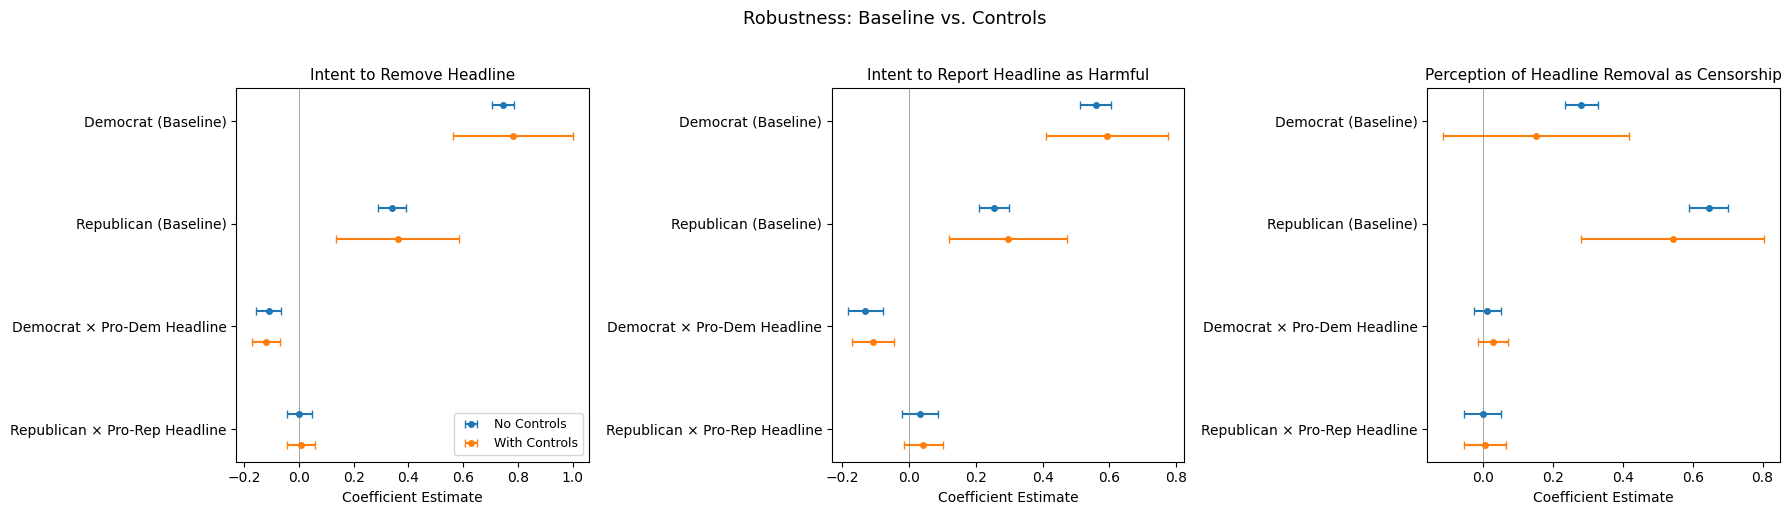

In [5]:
# Comparison: baseline vs. controls for main coefficients
coef_vars = {
    'C(party_id)[Democrat]': 'Democrat (Baseline)',
    'C(party_id)[Republican]': 'Republican (Baseline)',
    'party_id_dem:headline_pro_dem': 'Democrat × Pro-Dem Headline',
    'party_id_rep:headline_pro_rep': 'Republican × Pro-Rep Headline',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, outcome in zip(axes, ['remove', 'harm', 'censorship']):
    for label, res, color, offset in [('No Controls', results_base[outcome], '#1f77b4', -0.15),
                                       ('With Controls', results_ctrl[outcome], '#ff7f0e', 0.15)]:
        td = tidy(res)
        td = td[td['term'].isin(coef_vars.keys())].copy()
        td['label'] = td['term'].map(coef_vars)
        
        y_pos = {lbl: i for i, lbl in enumerate(coef_vars.values())}
        for _, row in td.iterrows():
            y = y_pos[row['label']] + offset
            ax.errorbar(row['estimate'], y,
                        xerr=[[row['estimate'] - row['conf_low']], [row['conf_high'] - row['estimate']]],
                        fmt='o', color=color, capsize=3, markersize=4, label=label if _ == td.index[0] else None)
    
    ax.axvline(0, color='grey', linewidth=0.5)
    ax.set_yticks(range(len(coef_vars)))
    ax.set_yticklabels(coef_vars.values())
    ax.set_title(OUTCOME_LABELS[outcome], fontsize=11)
    ax.set_xlabel('Coefficient Estimate')
    ax.invert_yaxis()

axes[0].legend(fontsize=9)
fig.suptitle('Robustness: Baseline vs. Controls', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

## 2. Multiple Imputation with Rubin's Rules

Pool results across 5 multiply-imputed datasets using Rubin's (1987) rules for combining estimates and standard errors.

In [6]:
results_mi = {}

for outcome in ['remove', 'harm', 'censorship']:
    formula = MAIN_FORMULA.format(outcome=outcome)
    pooled = pool_mi_results(formula, imputations, cluster_var='id', weight_var='weight')
    results_mi[outcome] = pooled
    
    print(f'\n=== {OUTCOME_LABELS[outcome]} (MI Pooled) ===')
    print(f'N = {pooled["nobs"]}, R² = {pooled["r_squared"]:.4f}')
    display(mi_results_to_df(pooled).round(4))


=== Intent to Remove Headline (MI Pooled) ===
N = 2240, R² = 0.1263


,term,estimate,std_error,p_value,conf_low,conf_high
0,C(party_id)[Democrat],0.7442,0.0207,0.0000,0.7035,0.7849
1,C(party_id)[Republican],0.3403,0.0257,0.0000,0.2898,0.3908
2,party_id_dem:headline_pro_dem,-0.1114,0.0228,0.0000,-0.1562,-0.0667
3,party_id_rep:headline_pro_rep,0.0041,0.0235,0.8614,-0.0420,0.0502



=== Intent to Report Headline as Harmful (MI Pooled) ===
N = 2240, R² = 0.0609


,term,estimate,std_error,p_value,conf_low,conf_high
0,C(party_id)[Democrat],0.5585,0.0231,0.0000,0.5133,0.6037
1,C(party_id)[Republican],0.2583,0.0237,0.0000,0.2118,0.3048
2,party_id_dem:headline_pro_dem,-0.1267,0.0268,0.0000,-0.1793,-0.0741
3,party_id_rep:headline_pro_rep,0.0304,0.0282,0.2811,-0.0249,0.0857



=== Perception of Headline Removal as Censorship (MI Pooled) ===
N = 2240, R² = 0.1041


,term,estimate,std_error,p_value,conf_low,conf_high
0,C(party_id)[Democrat],0.2975,0.0227,0.0000,0.2528,0.3422
1,C(party_id)[Republican],0.6285,0.0279,0.0000,0.5734,0.6836
2,party_id_dem:headline_pro_dem,0.0225,0.0255,0.3847,-0.0296,0.0745
3,party_id_rep:headline_pro_rep,0.0032,0.0296,0.9133,-0.0553,0.0618


In [7]:
# Compare listwise deletion vs. MI for main terms
print('Comparison: Listwise Deletion vs. Multiple Imputation')
print('=' * 80)

main_terms = ['C(party_id)[Democrat]', 'C(party_id)[Republican]',
              'party_id_dem:headline_pro_dem', 'party_id_rep:headline_pro_rep']

for outcome in ['remove', 'harm', 'censorship']:
    print(f'\n--- {outcome} ---')
    ld_td = tidy(results_base[outcome])
    mi_td = mi_results_to_df(results_mi[outcome])
    
    for term in main_terms:
        ld_row = ld_td[ld_td['term'] == term]
        mi_row = mi_td[mi_td['term'] == term]
        if ld_row.empty or mi_row.empty:
            continue
        ld_coef = ld_row['estimate'].values[0]
        mi_coef = mi_row['estimate'].values[0]
        ld_se = ld_row['std_error'].values[0]
        mi_se = mi_row['std_error'].values[0]
        se_diff_pct = (mi_se - ld_se) / ld_se * 100
        print(f'  {term:45s} LD: {ld_coef:7.4f} ({ld_se:.4f})  MI: {mi_coef:7.4f} ({mi_se:.4f})  SE diff: {se_diff_pct:+.1f}%')

Comparison: Listwise Deletion vs. Multiple Imputation

--- remove ---
  C(party_id)[Democrat]                         LD:  0.7455 (0.0205)  MI:  0.7442 (0.0207)  SE diff: +0.9%
  C(party_id)[Republican]                       LD:  0.3400 (0.0256)  MI:  0.3403 (0.0257)  SE diff: +0.5%
  party_id_dem:headline_pro_dem                 LD: -0.1100 (0.0228)  MI: -0.1114 (0.0228)  SE diff: +0.3%
  party_id_rep:headline_pro_rep                 LD:  0.0020 (0.0227)  MI:  0.0041 (0.0235)  SE diff: +3.7%

--- harm ---
  C(party_id)[Democrat]                         LD:  0.5586 (0.0233)  MI:  0.5585 (0.0231)  SE diff: -1.0%
  C(party_id)[Republican]                       LD:  0.2545 (0.0230)  MI:  0.2583 (0.0237)  SE diff: +2.9%
  party_id_dem:headline_pro_dem                 LD: -0.1301 (0.0267)  MI: -0.1267 (0.0268)  SE diff: +0.6%
  party_id_rep:headline_pro_rep                 LD:  0.0328 (0.0272)  MI:  0.0304 (0.0282)  SE diff: +3.7%

--- censorship ---
  C(party_id)[Democrat]                 

## 3. Consensus Headlines Analysis

Identify headlines that **both** parties rate as inaccurate (mean accuracy < 2). Then test whether results hold when restricting to progressively larger sets of consensus-false headlines.

In [8]:
# Compute mean accuracy by headline and party
rows = []
for (hl, pid), g in df.groupby(['headline', 'party_id'], observed=True):
    valid = g.dropna(subset=['accuracy', 'weight'])
    if len(valid) > 0:
        rows.append({
            'headline': hl,
            'party_id': pid,
            'mean_accuracy': np.average(valid['accuracy'], weights=valid['weight']),
        })

acc_by_hl = pd.DataFrame(rows)

acc_pivot = acc_by_hl.pivot(index='headline', columns='party_id', values='mean_accuracy')
acc_pivot['abs_diff'] = (acc_pivot['Democrat'] - acc_pivot['Republican']).abs()

# Consensus headlines: both parties rate < 2 ("not at all" or "not very" accurate)
consensus = acc_pivot[(acc_pivot['Democrat'] < 2) & (acc_pivot['Republican'] < 2)].copy()
consensus = consensus.sort_values('abs_diff')

print(f'Headlines rated as inaccurate by BOTH parties: {len(consensus)} of {len(acc_pivot)}')
display(consensus.round(3))

Headlines rated as inaccurate by BOTH parties: 9 of 18


party_id,Democrat,Republican,abs_diff
headline,,,
headline_pro_dem_4,1.550,1.538,0.012
headline_pro_rep_7,1.699,1.660,0.039
headline_pro_dem_1,1.730,1.662,0.068
headline_pro_dem_7,1.618,1.357,0.261
headline_pro_rep_9,1.226,1.601,0.375
headline_pro_dem_5,1.873,1.462,0.412
headline_pro_rep_2,1.505,1.980,0.475
headline_pro_rep_5,1.288,1.790,0.502
headline_pro_rep_3,1.245,1.840,0.595


In [9]:
# Run models on progressively larger consensus subsets
consensus_headlines = consensus.index.tolist()

consensus_results = {}
for n_hl in range(2, len(consensus_headlines) + 1):
    subset_hl = consensus_headlines[:n_hl]
    df_sub = df[df['headline'].isin(subset_hl)].copy()
    
    results_sub = {}
    for outcome in ['remove', 'harm', 'censorship']:
        formula = MAIN_FORMULA.format(outcome=outcome)
        try:
            res = fit_ols_clustered(formula, df_sub, cluster_var='id', weight_var='weight')
            results_sub[outcome] = res
        except Exception as e:
            print(f'  Skipping {outcome} with {n_hl} headlines: {e}')
    
    consensus_results[n_hl] = results_sub
    
    # Print summary
    print(f'\n--- {n_hl} consensus headlines (N obs ~ {len(df_sub)}) ---')
    for outcome, res in results_sub.items():
        dem = res.params.get('C(party_id)[Democrat]', np.nan)
        rep = res.params.get('C(party_id)[Republican]', np.nan)
        print(f'  {outcome}: D={dem:.3f}, R={rep:.3f}, gap={dem-rep:.3f}')


--- 2 consensus headlines (N obs ~ 250) ---
  remove: D=0.915, R=0.289, gap=0.626
  harm: D=0.660, R=0.263, gap=0.397
  censorship: D=0.387, R=0.791, gap=-0.404

--- 3 consensus headlines (N obs ~ 373) ---
  remove: D=0.915, R=0.367, gap=0.548
  harm: D=0.660, R=0.224, gap=0.435
  censorship: D=0.387, R=0.642, gap=-0.255

--- 4 consensus headlines (N obs ~ 479) ---
  remove: D=0.915, R=0.422, gap=0.492
  harm: D=0.660, R=0.260, gap=0.399
  censorship: D=0.387, R=0.630, gap=-0.243

--- 5 consensus headlines (N obs ~ 612) ---
  remove: D=0.805, R=0.422, gap=0.383
  harm: D=0.549, R=0.260, gap=0.288
  censorship: D=0.326, R=0.630, gap=-0.304

--- 6 consensus headlines (N obs ~ 739) ---
  remove: D=0.805, R=0.401, gap=0.404
  harm: D=0.549, R=0.284, gap=0.265
  censorship: D=0.326, R=0.625, gap=-0.299

--- 7 consensus headlines (N obs ~ 860) ---
  remove: D=0.772, R=0.401, gap=0.371
  harm: D=0.577, R=0.284, gap=0.293
  censorship: D=0.276, R=0.625, gap=-0.349

--- 8 consensus headlines (

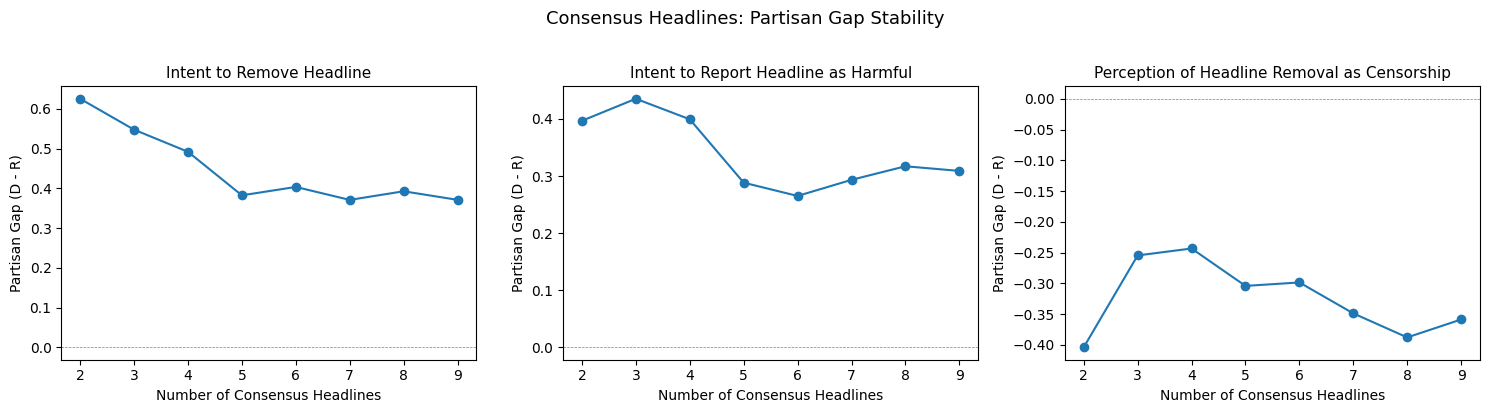

In [10]:
# Plot how partisan gap changes with number of consensus headlines
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, outcome in zip(axes, ['remove', 'harm', 'censorship']):
    n_hls = []
    gaps = []
    for n_hl, results_sub in sorted(consensus_results.items()):
        if outcome in results_sub:
            res = results_sub[outcome]
            dem = res.params.get('C(party_id)[Democrat]', np.nan)
            rep = res.params.get('C(party_id)[Republican]', np.nan)
            n_hls.append(n_hl)
            gaps.append(dem - rep)
    
    ax.plot(n_hls, gaps, 'o-', color='#1f77b4')
    ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
    ax.set_xlabel('Number of Consensus Headlines')
    ax.set_ylabel('Partisan Gap (D - R)')
    ax.set_title(OUTCOME_LABELS[outcome], fontsize=11)

fig.suptitle('Consensus Headlines: Partisan Gap Stability', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

## 4. MI with Controls

In [11]:
results_mi_ctrl = {}

for outcome in ['remove', 'harm', 'censorship']:
    formula = CTRL_FORMULA.format(outcome=outcome)
    pooled = pool_mi_results(formula, imputations, cluster_var='id', weight_var='weight')
    results_mi_ctrl[outcome] = pooled
    
    print(f'\n=== {OUTCOME_LABELS[outcome]} (MI + Controls) ===')
    print(f'N = {pooled["nobs"]}, R² = {pooled["r_squared"]:.4f}')
    display(mi_results_to_df(pooled).round(4))


=== Intent to Remove Headline (MI + Controls) ===
N = 2240, R² = 0.1415


,term,estimate,std_error,p_value,conf_low,conf_high
0,C(party_id)[Democrat],0.6835,0.0963,0.0000,0.4946,0.8724
1,C(party_id)[Republican],0.2957,0.0987,0.0028,0.1021,0.4893
2,party_id_dem:headline_pro_dem,-0.1108,0.0230,0.0000,-0.1559,-0.0656
3,party_id_rep:headline_pro_rep,0.0034,0.0237,0.8859,-0.0431,0.0500
4,age,0.0015,0.0009,0.1052,-0.0003,0.0034
5,gender,0.0343,0.0294,0.2438,-0.0234,0.0919
6,education,-0.0071,0.0153,0.6425,-0.0372,0.0230
7,household_income,-0.0009,0.0095,0.9236,-0.0196,0.0178
8,race_white,-0.0119,0.0322,0.7120,-0.0751,0.0513
9,hispanic,0.0932,0.0402,0.0205,0.0144,0.1720



=== Intent to Report Headline as Harmful (MI + Controls) ===
N = 2240, R² = 0.0770


,term,estimate,std_error,p_value,conf_low,conf_high
0,C(party_id)[Democrat],0.5461,0.0839,0.0000,0.3817,0.7106
1,C(party_id)[Republican],0.2509,0.0844,0.0030,0.0853,0.4165
2,party_id_dem:headline_pro_dem,-0.1262,0.0270,0.0000,-0.1791,-0.0733
3,party_id_rep:headline_pro_rep,0.0301,0.0282,0.2850,-0.0252,0.0854
4,age,0.0027,0.0009,0.0018,0.0010,0.0044
5,gender,-0.0476,0.0273,0.0819,-0.1013,0.0060
6,education,-0.0087,0.0142,0.5403,-0.0365,0.0191
7,household_income,-0.0041,0.0093,0.6588,-0.0222,0.0141
8,race_white,-0.0250,0.0327,0.4449,-0.0893,0.0392
9,hispanic,0.0060,0.0410,0.8829,-0.0744,0.0865



=== Perception of Headline Removal as Censorship (MI + Controls) ===
N = 2240, R² = 0.1166


,term,estimate,std_error,p_value,conf_low,conf_high
0,C(party_id)[Democrat],0.3147,0.1106,0.0054,0.0952,0.5343
1,C(party_id)[Republican],0.6323,0.1081,0.0000,0.4190,0.8455
2,party_id_dem:headline_pro_dem,0.0216,0.0259,0.4123,-0.0315,0.0747
3,party_id_rep:headline_pro_rep,0.0044,0.0303,0.8855,-0.0557,0.0645
4,age,0.0002,0.0010,0.8719,-0.0018,0.0021
5,gender,-0.0127,0.0325,0.6983,-0.0773,0.0520
6,education,0.0050,0.0166,0.7663,-0.0281,0.0380
7,household_income,-0.0019,0.0102,0.8557,-0.0219,0.0182
8,race_white,-0.0114,0.0341,0.7391,-0.0783,0.0556
9,hispanic,-0.1066,0.0454,0.0193,-0.1959,-0.0174


## 5. Robustness Comparison Summary

In [12]:
# Summary table: Democrat baseline and interaction across specifications
summary_rows = []
main_terms = ['C(party_id)[Democrat]', 'C(party_id)[Republican]',
              'party_id_dem:headline_pro_dem', 'party_id_rep:headline_pro_rep']

specs = {
    'Baseline (LD)': results_base,
    'Controls (LD)': results_ctrl,
    'Baseline (MI)': results_mi,
    'Controls (MI)': results_mi_ctrl,
}

for spec_name, spec_results in specs.items():
    for outcome in ['remove', 'harm', 'censorship']:
        res = spec_results[outcome]
        if isinstance(res, dict):  # MI pooled
            td = mi_results_to_df(res)
        else:
            td = tidy(res)
        
        for term in main_terms:
            row = td[td['term'] == term]
            if row.empty:
                continue
            summary_rows.append({
                'Specification': spec_name,
                'Outcome': outcome,
                'Term': term,
                'Coef': round(row['estimate'].values[0], 4),
                'SE': round(row['std_error'].values[0], 4),
            })

summary_df = pd.DataFrame(summary_rows)
for outcome in ['remove', 'harm', 'censorship']:
    print(f'\n=== {outcome} ===')
    display(summary_df[summary_df['Outcome'] == outcome].pivot(
        index='Term', columns='Specification', values='Coef'
    ).round(4))


=== remove ===


Specification,Baseline (LD),Baseline (MI),Controls (LD),Controls (MI)
Term,,,,
C(party_id)[Democrat],0.7455,0.7442,0.7813,0.6835
C(party_id)[Republican],0.3400,0.3403,0.3613,0.2957
party_id_dem:headline_pro_dem,-0.1100,-0.1114,-0.1190,-0.1108
party_id_rep:headline_pro_rep,0.0020,0.0041,0.0081,0.0034



=== harm ===


Specification,Baseline (LD),Baseline (MI),Controls (LD),Controls (MI)
Term,,,,
C(party_id)[Democrat],0.5586,0.5585,0.5936,0.5461
C(party_id)[Republican],0.2545,0.2583,0.2960,0.2509
party_id_dem:headline_pro_dem,-0.1301,-0.1267,-0.1075,-0.1262
party_id_rep:headline_pro_rep,0.0328,0.0304,0.0430,0.0301



=== censorship ===


Specification,Baseline (LD),Baseline (MI),Controls (LD),Controls (MI)
Term,,,,
C(party_id)[Democrat],0.2809,0.2975,0.1523,0.3147
C(party_id)[Republican],0.6462,0.6285,0.5423,0.6323
party_id_dem:headline_pro_dem,0.0125,0.0225,0.0294,0.0216
party_id_rep:headline_pro_rep,-0.0015,0.0032,0.0052,0.0044


## Summary

Robustness checks confirm:
1. **Adding controls** barely changes the main coefficients — the partisan gap is not driven by demographic confounders
2. **Multiple imputation** yields very similar point estimates; SEs are slightly larger (appropriately accounting for missing data uncertainty)
3. **Consensus headlines**: Even restricting to headlines both parties agree are false, large partisan gaps in moderation preferences persist